# 🏞️ **Water Quality Prediction and Contamination Detection using **Machine** Learning**

## 🎛️ **Preliminaries**

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data manipulation and analysis
import numpy as np
import pandas as pd

# Feature preprocessing and data splitting
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning & Deep Learning
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
import pickle

# Others
from tqdm import tqdm
import os

# Planetary Computer tools
from odc.stac import stac_load
import planetary_computer

# Google Cloud
from google.cloud import bigquery

In [2]:
base_dir = os.getcwd()
print(f"Base directory: {base_dir}")

data_dir = os.path.join(base_dir, "data")
model_dir = os.path.join(base_dir, "model")
os.makedirs(data_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

Base directory: /home/jupyter/src


In [3]:
client = bigquery.Client()

# Query final processed dataset
query = """
SELECT *
FROM `river-water-quality-prediction.river_water_quality_dataset.final_river_water_quality`
"""

# Load into pandas dataframe
Cleaned_River_Water_Quality_df = client.query(query).to_dataframe()

data_path = os.path.join(os.getcwd(), "data", "final_river_water_quality.csv")

# Save locally inside workbench
Cleaned_River_Water_Quality_df.to_csv(data_path, index=False)

print(f"Dataset saved to: {data_path}")
print(Cleaned_River_Water_Quality_df.shape)

Dataset saved to: /home/jupyter/src/data/final_river_water_quality.csv
(35433, 34)


In [4]:
Cleaned_River_Water_Quality_df.head(10)

,River,Date,Latitude,Longitude,EC,Temp_C,SS_mgL,pH,TP_mgL,NO2_N_mgL,...,red,blue,Country,NDVI,NDWI,MNDWI,NDBI,NDMI,NDTI,WQI
0,Mui Wo River,2005-05-12,22.265083,113.993833,30304.0,25.7,4.0,7.5,0.07,0.023,...,9936.0,9515.5,Hong Kong,0.736694,0.0,0.607156,-0.607156,0.607156,-0.736694,58.476165
1,Mui Wo River,2006-04-21,22.265083,113.993833,44204.0,25.3,12.0,7.4,0.08,0.010,...,65535.0,65535.0,Hong Kong,0.000000,0.0,0.565146,-0.565146,0.565146,0.000000,54.304389
2,Mui Wo River,2006-05-25,22.265083,113.993833,21510.0,28.3,24.0,7.0,0.15,0.016,...,65535.0,65535.0,Hong Kong,0.000000,0.0,0.565146,-0.565146,0.565146,0.000000,60.933158
3,Mui Wo River,2006-06-28,22.265083,113.993833,22166.0,28.2,7.4,7.6,0.10,0.014,...,65535.0,65535.0,Hong Kong,0.000000,0.0,0.565146,-0.565146,0.565146,0.000000,62.530367
4,Mui Wo River,2009-06-10,22.265083,113.993833,12222.0,27.8,54.0,8.0,0.13,0.012,...,9984.0,9324.5,Hong Kong,0.735590,0.0,0.564361,-0.564361,0.564361,-0.735590,64.919309
5,Mui Wo River,2003-05-26,22.265083,113.993833,7318.0,31.5,12.0,7.4,0.16,0.012,...,65535.0,65535.0,Hong Kong,0.000000,0.0,0.531022,-0.531022,0.531022,0.000000,78.955818
6,Mui Wo River,2003-06-12,22.265083,113.993833,3032.0,27.1,9.8,6.9,0.16,0.006,...,10262.0,10028.0,Hong Kong,0.729224,0.0,0.531022,-0.531022,0.531022,-0.729224,89.220172
7,Mui Wo River,2011-04-13,22.265083,113.993833,26181.0,26.5,7.4,7.6,0.11,0.014,...,65535.0,65535.0,Hong Kong,0.000000,0.0,0.408257,-0.408257,0.408257,0.000000,60.309939
8,Mui Wo River,2011-03-10,22.265083,113.993833,35729.0,17.7,7.8,7.1,0.08,0.015,...,10319.0,9539.5,Hong Kong,0.727925,0.0,0.408257,-0.408257,0.408257,-0.727925,56.553919
9,Mui Wo River,2005-04-15,22.265083,113.993833,42076.0,21.1,2.7,7.8,0.06,0.026,...,65535.0,65535.0,Hong Kong,0.000000,0.0,0.397454,-0.397454,0.397454,0.000000,54.801912


In [5]:
print(Cleaned_River_Water_Quality_df.isna().sum())

River        0
Date         0
Latitude     0
Longitude    0
EC           0
Temp_C       0
SS_mgL       0
pH           0
TP_mgL       0
NO2_N_mgL    0
NO3_N_mgL    0
DO_mgL       0
Al_mgL       0
Fe_mgL       0
Mn_mgL       0
Zn_mgL       0
Cu_mgL       0
Chl_a_mgL    0
lat_round    0
lon_round    0
nir          0
green        0
swir16       0
swir22       0
red          0
blue         0
Country      0
NDVI         0
NDWI         0
MNDWI        0
NDBI         0
NDMI         0
NDTI         0
WQI          0
dtype: int64


## 📊 **Exploratory Data Analysis (EDA)**

### 📍 **In-Situ EDA**

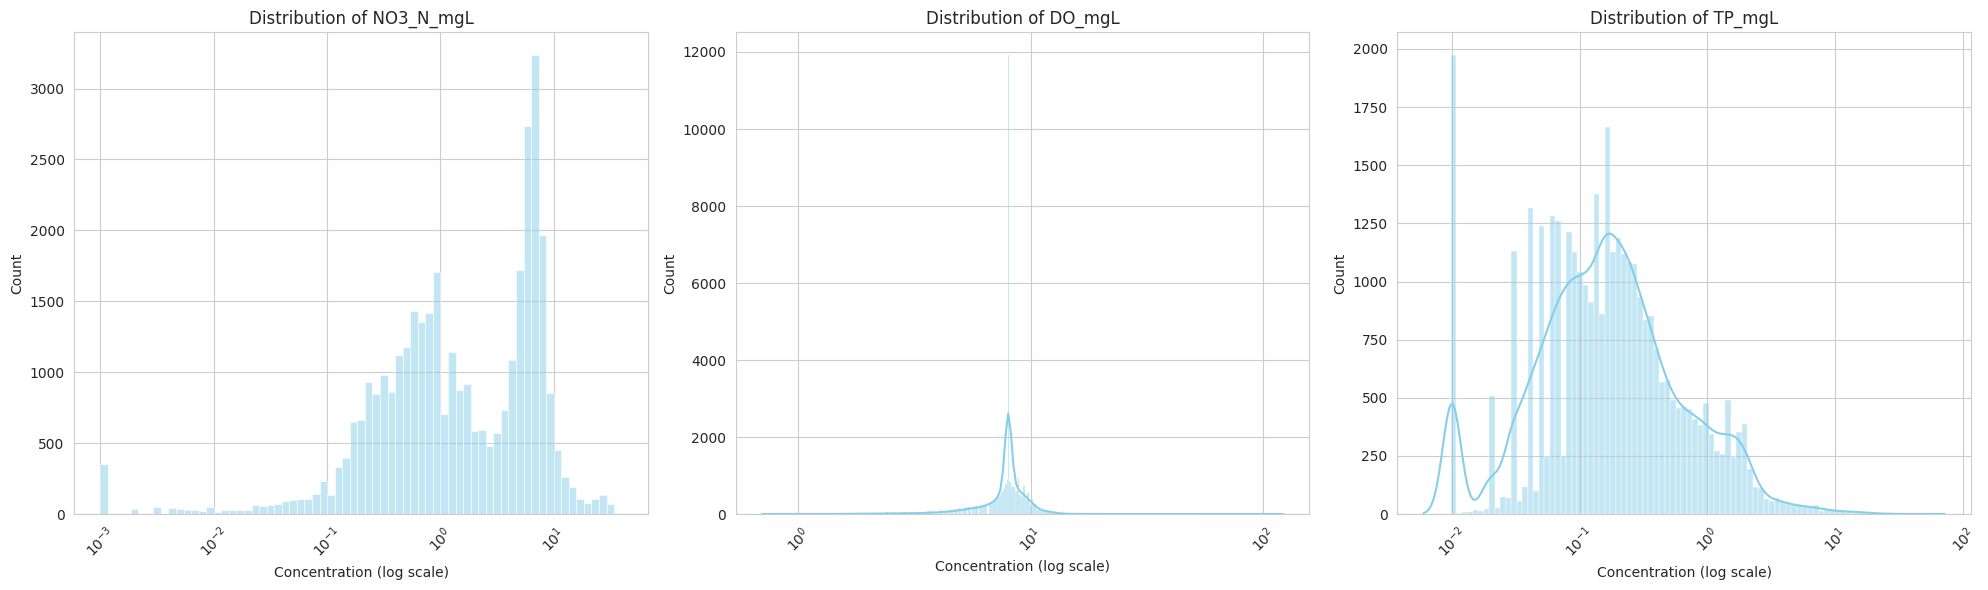

In [12]:
# Univariate Distribution Analysis This helps identify outliers and the distribution shape of key metrics
# Set plot style
sns.set_style("whitegrid")

# Select numeric columns
cols_to_plot = ['NO3_N_mgL', 'DO_mgL', 'TP_mgL']

# Create subplots with adjusted spacing
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(cols_to_plot):
    if col in Cleaned_River_Water_Quality_df.columns:
        # Use log_scale=True to handle skewed water quality data
        # This makes the distribution visible instead of one giant spike
        sns.histplot(Cleaned_River_Water_Quality_df[col], kde=True, ax=axes[i], color='skyblue', log_scale=True)

        # Set title and labels
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('Concentration (log scale)')

        # Rotate x-axis labels to prevent overlap
        axes[i].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()

In [13]:
# Time Series Trend Analysis Observing how water quality metrics have evolved over the years
# Convert Date column to datetime
Cleaned_River_Water_Quality_df['Date'] = pd.to_datetime(Cleaned_River_Water_Quality_df['Date'], errors='coerce')

# Extract year and calculate the yearly average
Cleaned_River_Water_Quality_df['Year'] = Cleaned_River_Water_Quality_df['Date'].dt.year

# Group by Year and Country
yearly_country_avg = Cleaned_River_Water_Quality_df.groupby(['Year', 'Country'])[['NO3_N_mgL', 'DO_mgL', 'TP_mgL']].mean().reset_index()

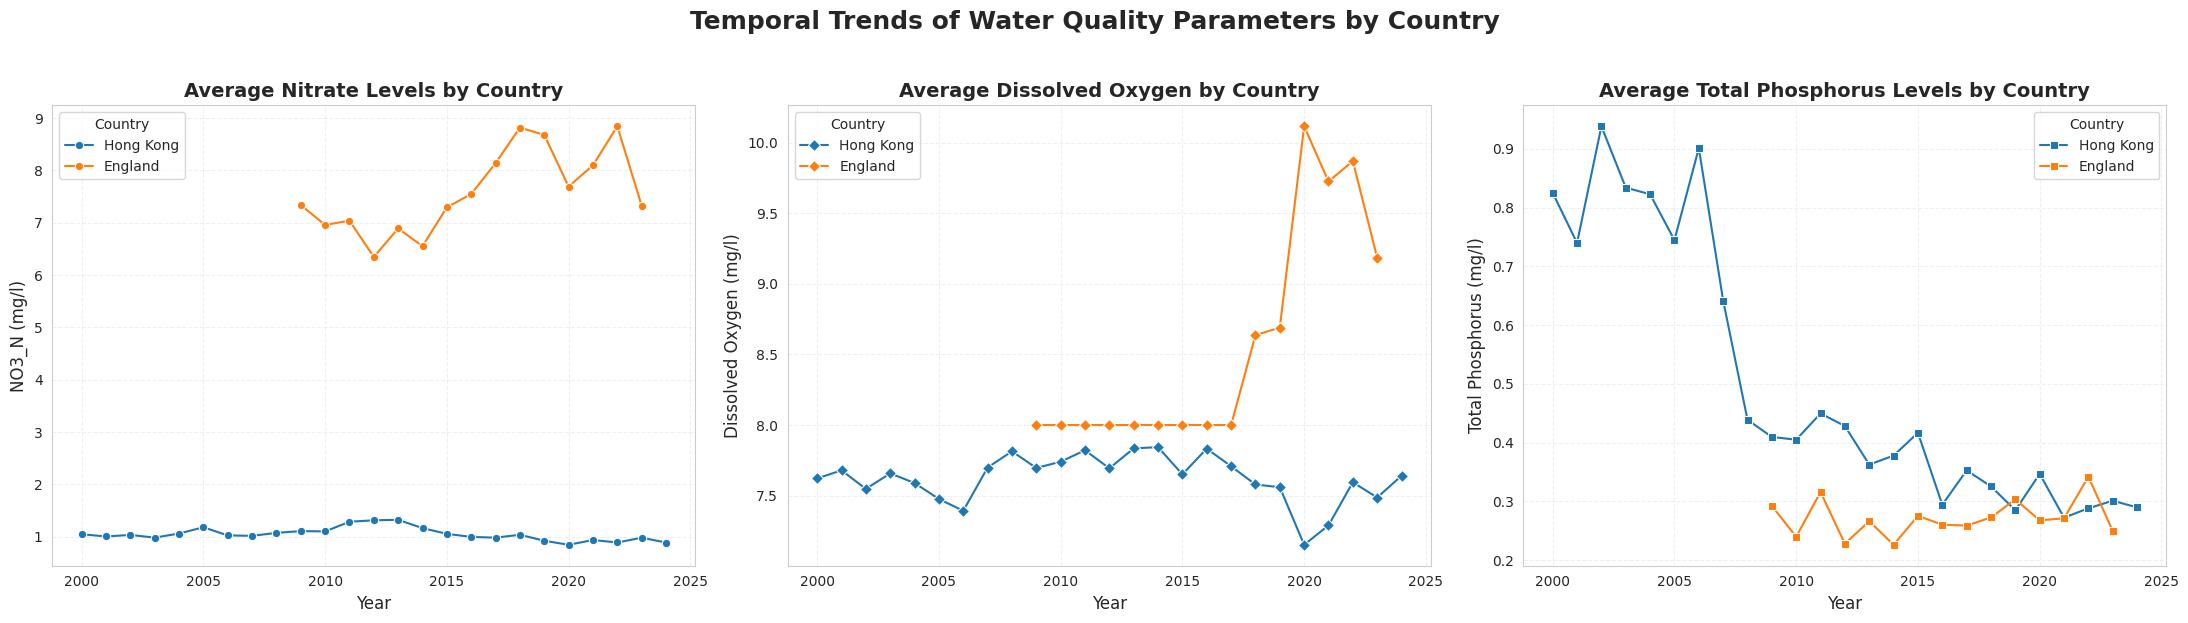

In [14]:
# Plot Trends
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharex=True)

# --- Plot 1: Nitrate Trends ---
sns.lineplot(data=yearly_country_avg, x='Year', y='NO3_N_mgL',
             hue='Country', marker='o', ax=axes[0])

axes[0].set_title('Average Nitrate Levels by Country', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('NO3_N (mg/l)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.3)

# --- Plot 2: Dissolved Oxygen Trends ---
sns.lineplot(data=yearly_country_avg, x='Year', y='DO_mgL',
             hue='Country', marker='D', ax=axes[1])

axes[1].set_title('Average Dissolved Oxygen by Country', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Dissolved Oxygen (mg/l)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.3)

# --- Plot 3: Orthophosphate Trends ---
sns.lineplot(data=yearly_country_avg, x='Year', y='TP_mgL',
             hue='Country', marker='s', ax=axes[2])

axes[2].set_title('Average Total Phosphorus Levels by Country', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Year', fontsize=12)
axes[2].set_ylabel('Total Phosphorus (mg/l)', fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.3)

fig.suptitle(
    'Temporal Trends of Water Quality Parameters by Country',
    fontsize=18,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()
plt.show()

### 🛰️ **Satellite EDA**

In [13]:
# Define the bounding box for the entire data region using (Latitude, Longitude)
sample = Cleaned_River_Water_Quality_df.sample(1)

# Extract lat and lon coordinates
lat = sample['Latitude'].values[0]
lon = sample['Longitude'].values[0]
date = pd.to_datetime(sample['Date'].values[0])

In [15]:
import pystac_client
import planetary_computer

stac = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

In [16]:
for idx, row in Cleaned_River_Water_Quality_df.iterrows():

    # Define the bounding box for the entire data region using (Latitude, Longitude)
    lat = row["Latitude"]
    lon = row["Longitude"]
    date = pd.to_datetime(row["Date"])
    
    # Calculate the bounds for doing an archive data search
    # bounds = (min_lon, min_lat, max_lon, max_lat)
    bounds = (
        lon - 0.1,
        lat - 0.1,
        lon + 0.1,
        lat + 0.1
    )

    time_window = (
        f"{date.strftime('%Y-%m-%d')}/"
        f"{(date + pd.Timedelta(days=30)).strftime('%Y-%m-%d')}"
    )

    search_landsat = stac.search(
        collections=["landsat-c2-l2"],
        bbox=bounds,
        datetime=time_window,
        query={"eo:cloud_cover": {"lt": 10}},
        limit=10
    )

    items = list(search_landsat.items())

    if len(items) == 0:
        continue

    print("Scene found!")
    break

Scene found!


In [17]:
items_landsat = list(search_landsat.get_items())

print('This is the number of scenes that touch our region:',len(items_landsat))

This is the number of scenes that touch our region: 2


In [18]:
import planetary_computer

signed_items_landsat = [planetary_computer.sign(item) for item in items_landsat]

In [19]:
# Define the pixel resolution for the final product
# Define the scale according to our selected crs, so we will use degrees
resolution = 10  # meters per pixel
scale = resolution / 111320.0 # degrees per pixel for crs=4326

In [20]:
from odc.stac import stac_load

data_landsat = stac_load(
    signed_items_landsat,
    bands=["red", "green", "blue", "nir08", "swir16", "swir22"],
    crs="EPSG:4326",
    resolution=scale,
    chunks={"x": 2048, "y": 2048},
    dtype="uint16",
    patch_url=planetary_computer.sign,
    bbox=bounds
)

In [21]:
# View the dimensions of our XARRAY and the loaded variables
# This insures we have the right coordinates and spectral bands in our xarray
print(data_landsat)

<xarray.Dataset> Size: 119MB
Dimensions:      (latitude: 2228, longitude: 2227, time: 2)
Coordinates:
  * latitude     (latitude) float64 18kB 22.37 22.37 22.36 ... 22.17 22.17 22.17
  * longitude    (longitude) float64 18kB 113.9 113.9 113.9 ... 114.1 114.1
  * time         (time) datetime64[ns] 16B 2019-06-08T02:36:12.362844 2019-06...
    spatial_ref  int32 4B 4326
Data variables:
    red          (time, latitude, longitude) uint16 20MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    green        (time, latitude, longitude) uint16 20MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    blue         (time, latitude, longitude) uint16 20MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    nir08        (time, latitude, longitude) uint16 20MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    swir16       (time, latitude, longitude) uint16 20MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    swir22       (time, latitude, longitude) uint16 2

In [22]:
# Persist the data in memory for faster operations
data_landsat = data_landsat.persist()

In [23]:
# Scale Factors for the RGB and NIR bands
scale = 0.0000275
offset = -0.2
data_landsat = data_landsat.astype(float) * scale + offset

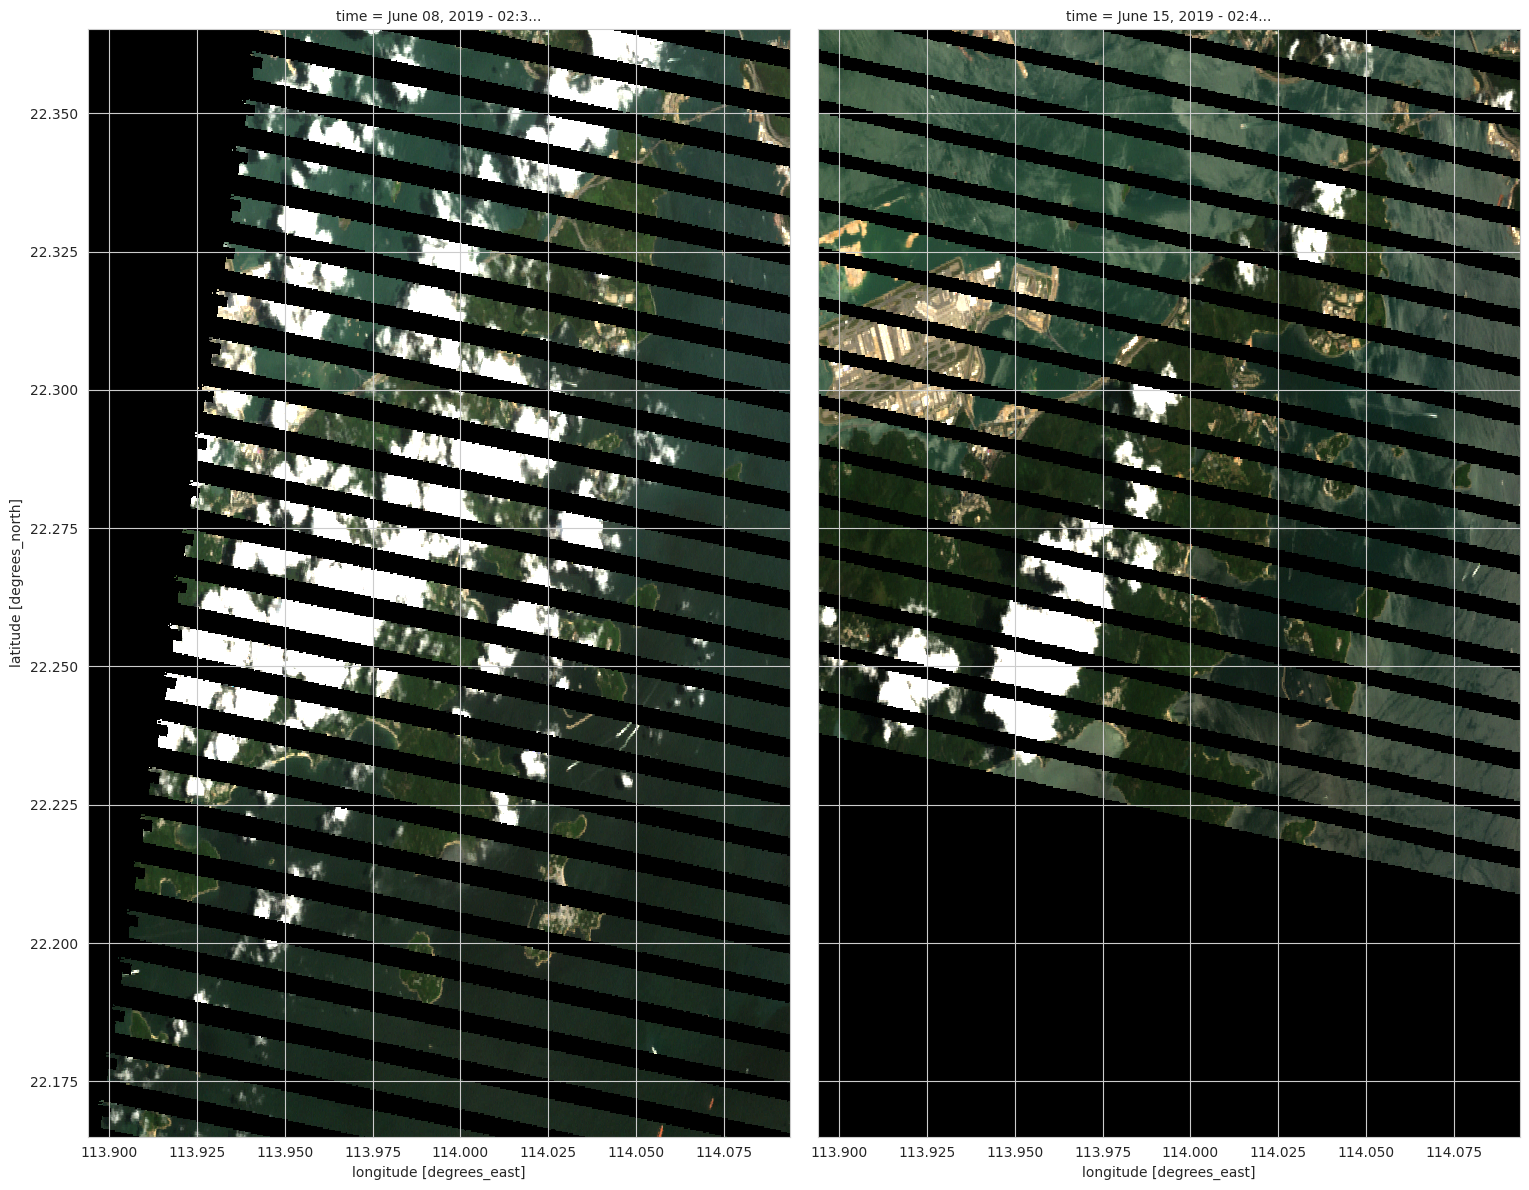

In [24]:
plot_data_landsat = data_landsat[["red","green","blue"]].to_array()

# Format the time axis with readable date strings
formatted_time = pd.to_datetime(plot_data_landsat["time"].values).strftime("%B %d, %Y - %I:%M %p")
unique_time_labels = [f"{t} ({i})" for i, t in enumerate(formatted_time)]

# Reassign the formatted time labels back to the array
plot_data_landsat.coords["time"] = ("time", unique_time_labels)

plot_data_landsat.plot.imshow(col='time', col_wrap=4, figsize = (30,12), robust=True, vmin=0, vmax=0.25)
plt.show()

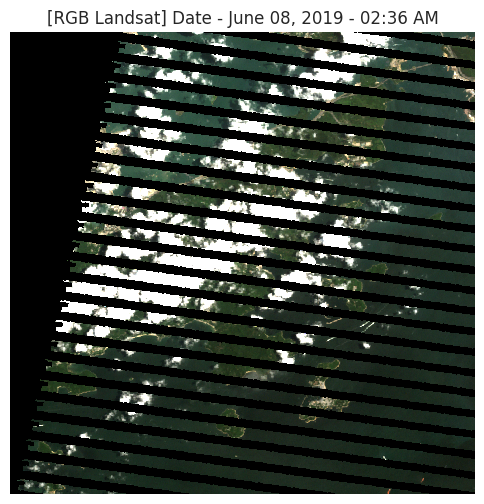

In [25]:
# Plot an image for a single date (Landsat)
time_index = 0

selected_time = pd.to_datetime(data_landsat.time.values[time_index]).strftime("%B %d, %Y - %I:%M %p")
fig, ax = plt.subplots(figsize=(6,6))
data_landsat.isel(time=time_index)[["red", "green", "blue"]].to_array().plot.imshow(robust=True, ax=ax, vmin=0.0, vmax=0.25)
ax.set_title(f"[RGB Landsat] Date - {selected_time}")
ax.axis('off')
plt.show()

In [26]:
median_landsat = data_landsat.median(dim="time").compute()

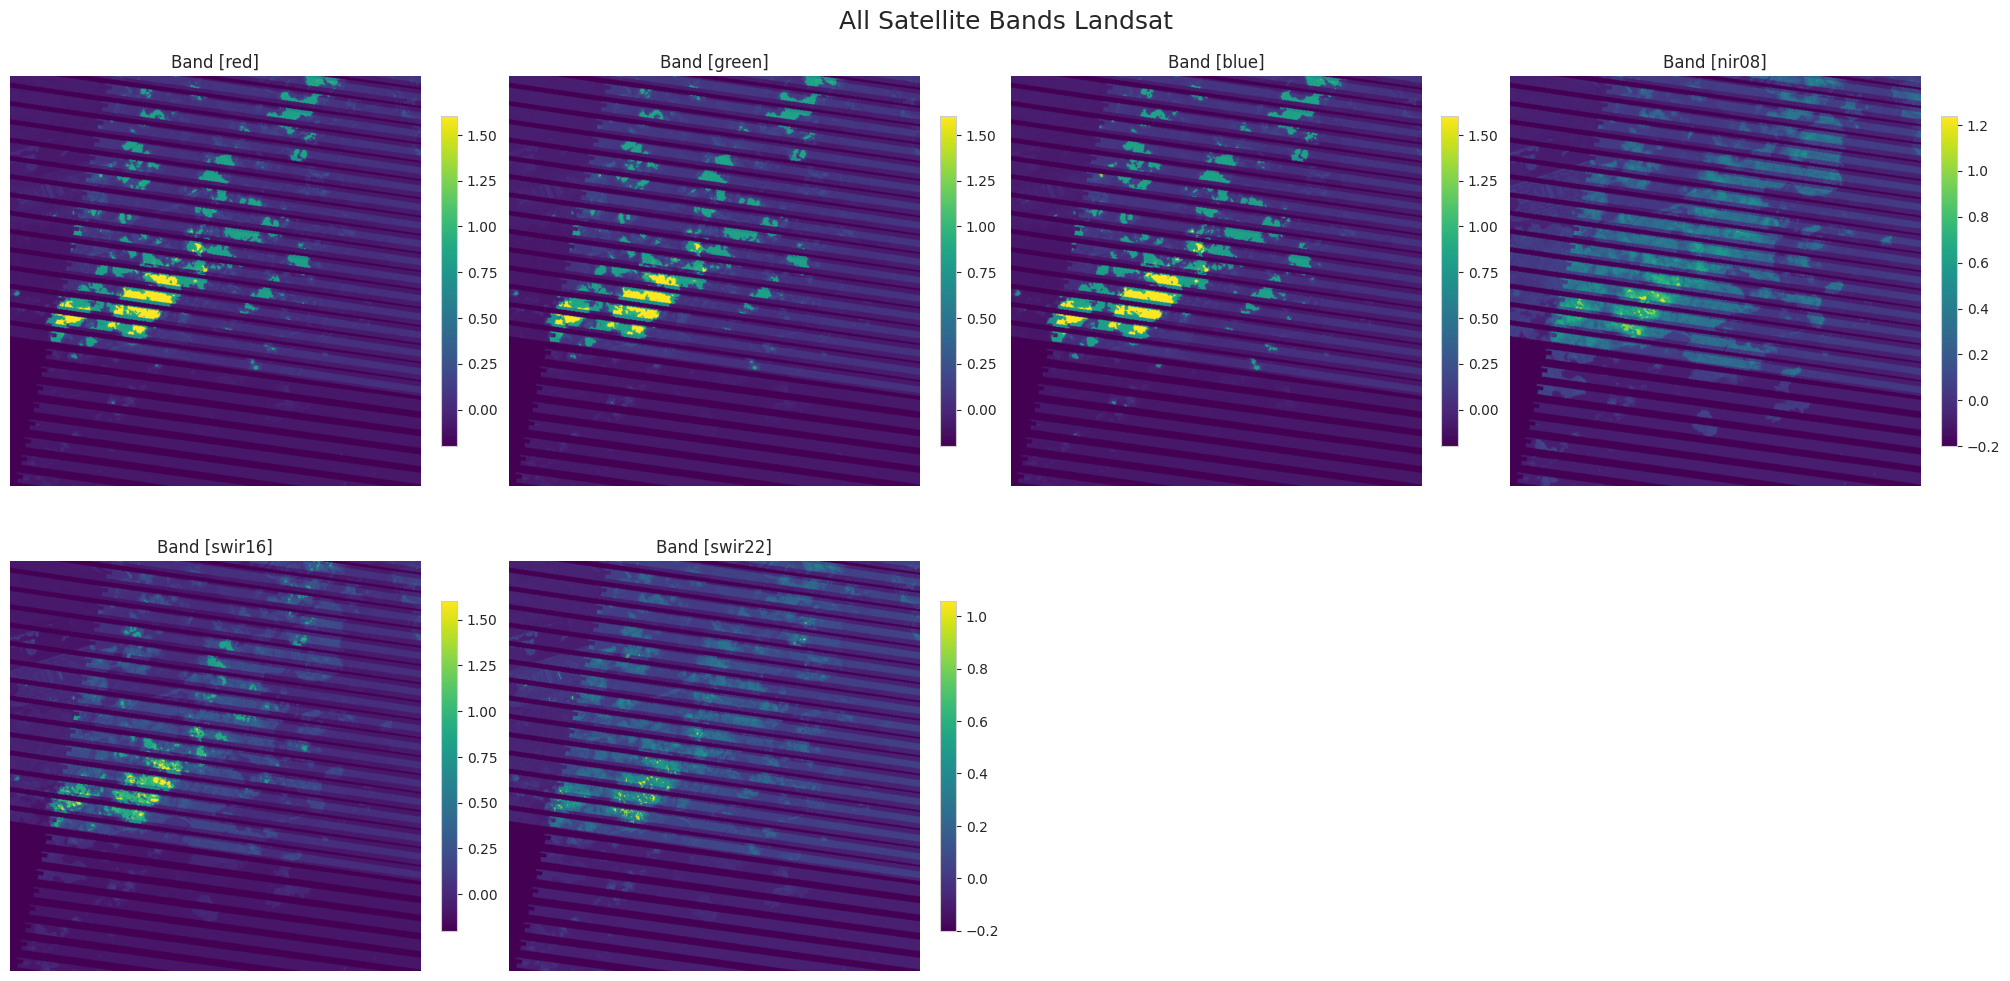

In [27]:
import math

# Get the list of band names from the median composite
band_names = list(median_landsat.data_vars)
num_bands = len(band_names)

cols = 4
rows = math.ceil(num_bands / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 5), constrained_layout=True)
axes = axes.flatten()

# Plot each band
for i, band in enumerate(band_names):
  im = axes[i].imshow(median_landsat[band], cmap='viridis')
  axes[i].set_title(f"Band [{band}]", fontsize=12)
  axes[i].axis('off')
  fig.colorbar(im, ax=axes[i], shrink=0.7)

# Turn off any unused axes
for j in range(i + 1, len(axes)):
  axes[j].remove()

plt.suptitle("All Satellite Bands Landsat", fontsize=18)
plt.show()

In [28]:
# Calculate derived indices from median Landsat mosaic
eps = 1e-6

# NDVI
ndvi_median_landsat = ((median_landsat.nir08 - median_landsat.red) / (median_landsat.nir08 + median_landsat.red + eps))

# NDWI
ndwi_median_landsat = ((median_landsat.green - median_landsat.nir08) / (median_landsat.green + median_landsat.nir08 + eps))

# MNDWI
mndwi_median_landsat = ((median_landsat.green - median_landsat.swir16) / (median_landsat.green + median_landsat.swir16 + eps))

# NDBI
ndbi_median_landsat = ((median_landsat.swir16 - median_landsat.nir08) / (median_landsat.swir16 + median_landsat.nir08 + eps)) 

# NDMI
ndmi_median_landsat = ((median_landsat.nir08 - median_landsat.swir16) / (median_landsat.nir08 + median_landsat.swir16 + eps))

# NDTI
ndti_median_landsat = ((median_landsat.red - median_landsat.green) / (median_landsat.red + median_landsat.green + eps))

# Store indices and plotting configs
indices = {
    "NDVI": (ndvi_median_landsat, "RdYlGn", -1, 1),
    "NDWI": (ndwi_median_landsat, "Blues", -1, 1),
    "MNDWI": (mndwi_median_landsat, "PuBu", -1, 1),
    "NDBI": (ndbi_median_landsat, "jet", -1, 1),
    "NDMI": (ndmi_median_landsat, "BrBG", -1, 1),
    "NDTI": (ndti_median_landsat, "RdBu", -1, 1),
}

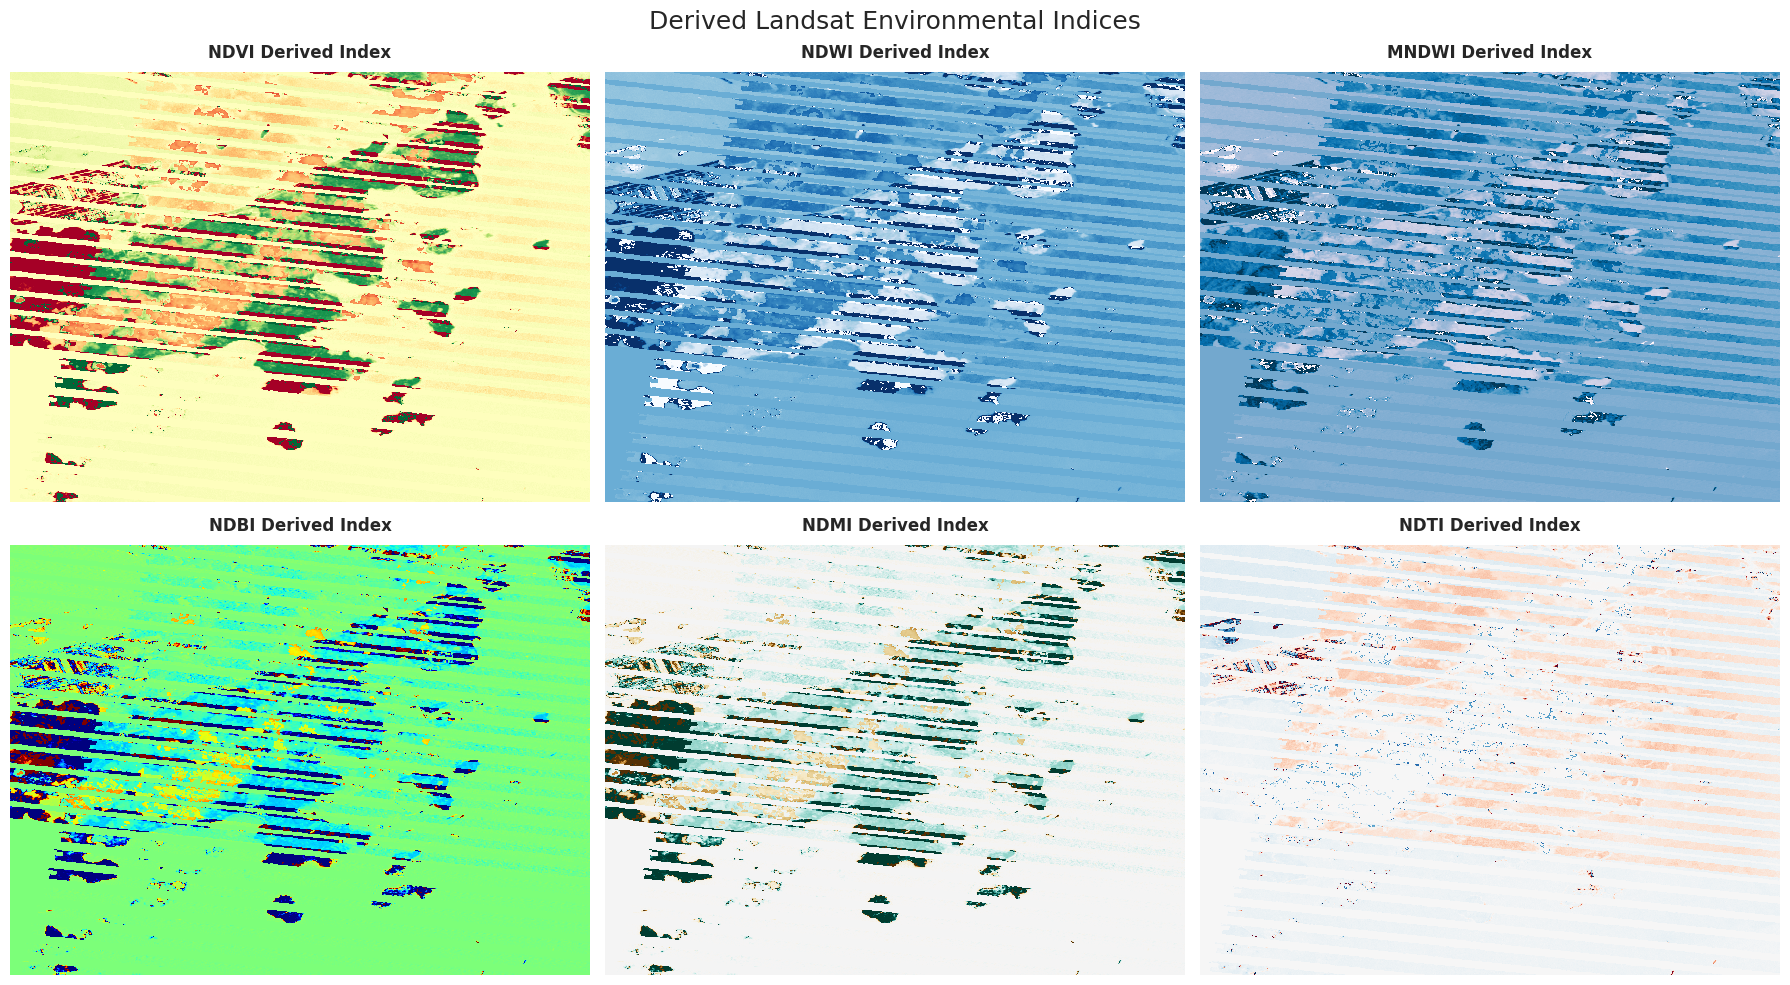

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Plot all indices
for ax, (index_name, (index_data, cmap, vmin, vmax)) in zip(axes, indices.items()):

    index_data.plot.imshow(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_title(f"{index_name} Derived Index", fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')

plt.suptitle("Derived Landsat Environmental Indices", fontsize=18, y=0.98)

plt.tight_layout()
plt.show()

In [15]:
numeric_cols = Cleaned_River_Water_Quality_df.select_dtypes(include=np.number)

skewness = Cleaned_River_Water_Quality_df[numeric_cols.columns].skew()

print(skewness.sort_values(ascending=False))

Zn_mgL       71.057864
SS_mgL       43.358610
Cu_mgL       43.333737
Mn_mgL       32.983147
TP_mgL       20.766877
DO_mgL       19.411625
Al_mgL       17.298997
Fe_mgL       14.265844
Chl_a_mgL    12.604381
swir16        6.289797
NO2_N_mgL     6.249847
swir22        5.631447
green         4.533682
red           4.376335
nir           4.320041
blue          3.981232
MNDWI         3.494194
EC            2.858441
NO3_N_mgL     2.508324
NDMI          1.649130
pH            1.306606
NDWI          1.008296
Latitude      0.589423
lat_round     0.589423
NDTI          0.161691
Year         -0.240593
Temp_C       -0.436041
lon_round    -0.589382
Longitude    -0.589382
WQI          -0.686437
NDVI         -1.506110
NDBI         -1.649130
dtype: float64


WQI          1.000000
EC           0.548818
TP_mgL       0.359391
NO2_N_mgL    0.303661
DO_mgL       0.293339
Mn_mgL       0.282586
Al_mgL       0.259678
Fe_mgL       0.256088
Cu_mgL       0.242514
SS_mgL       0.190073
NDWI         0.165575
NDVI         0.129261
pH           0.114917
NDBI         0.100581
NDMI         0.100581
NO3_N_mgL    0.085817
MNDWI        0.083358
Zn_mgL       0.079417
Chl_a_mgL    0.053808
nir          0.033027
blue         0.032724
red          0.030880
swir22       0.029036
green        0.023506
NDTI         0.017333
Temp_C       0.015298
swir16       0.002593
Name: WQI, dtype: float64


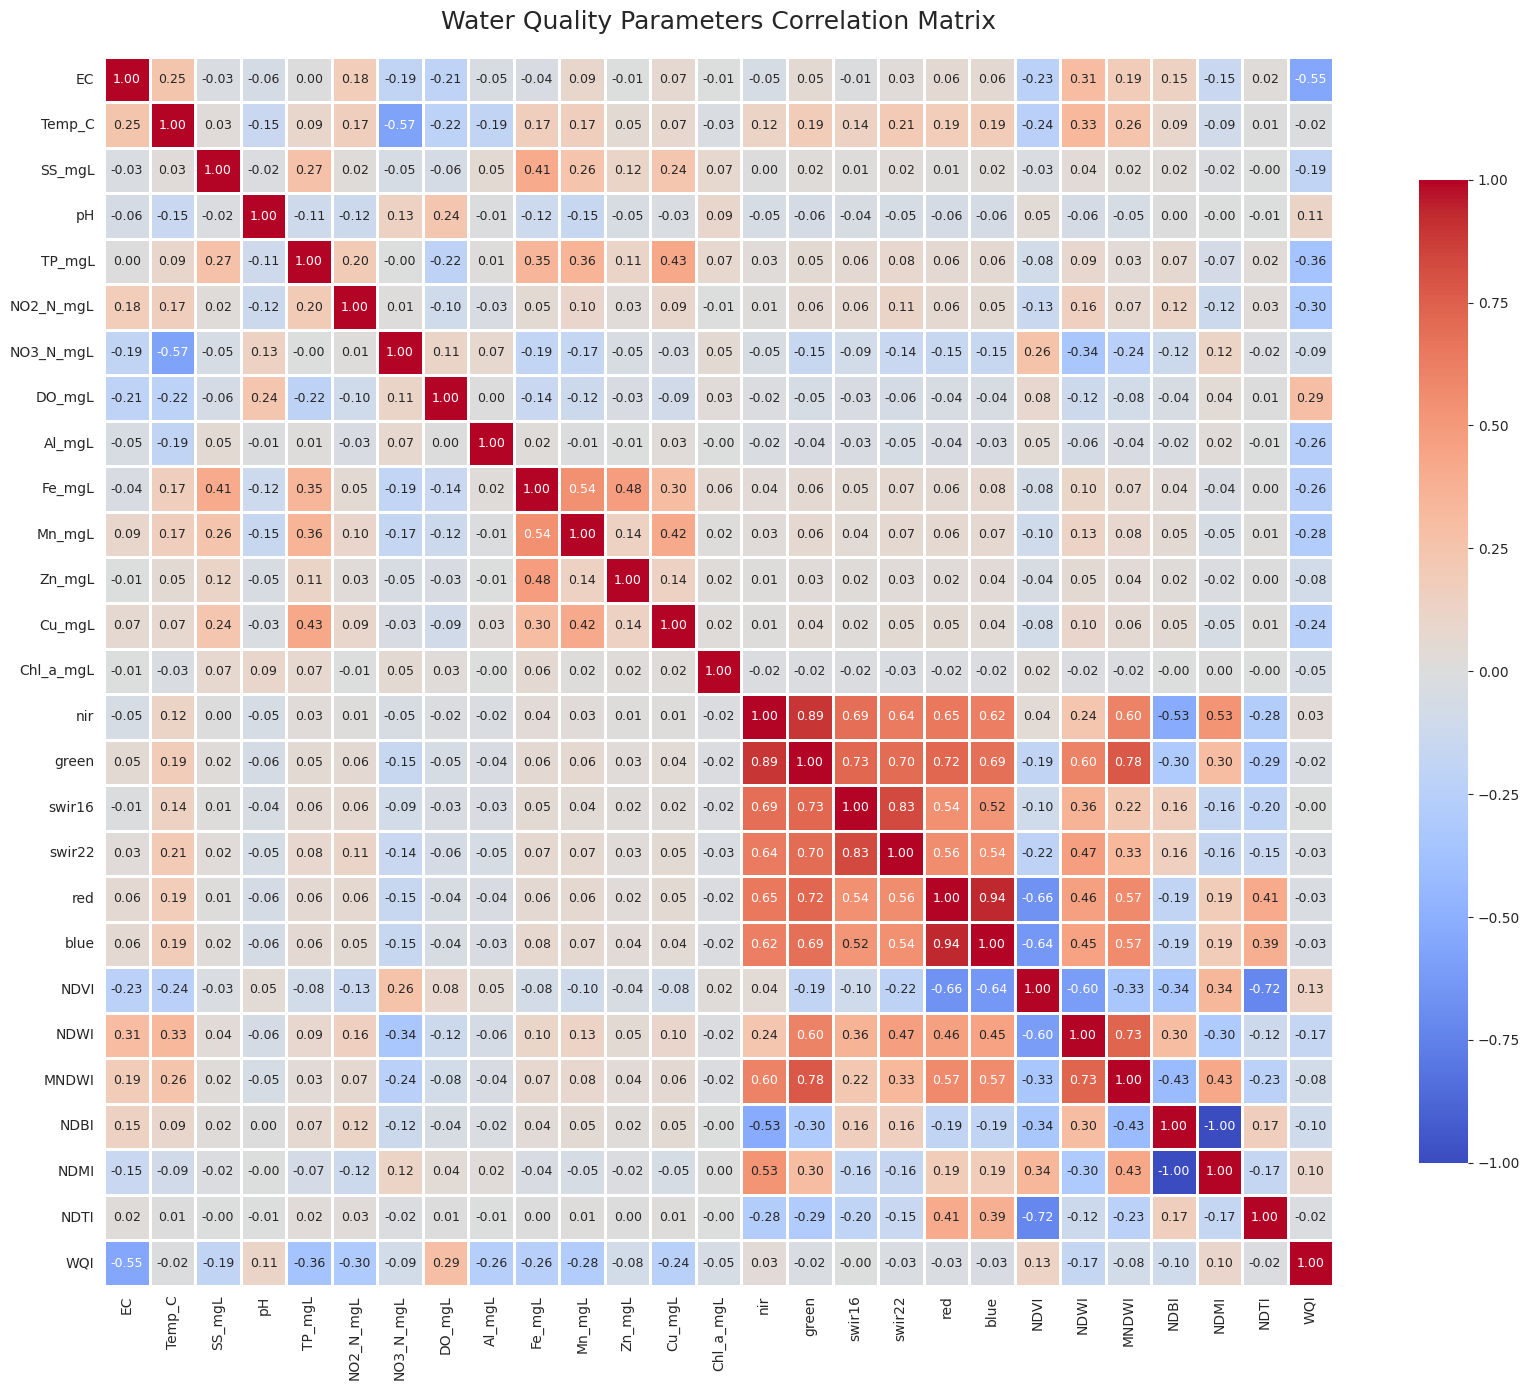

In [16]:
# Correlation Analysis Using a heatmap to identify linear relationships between features

# Define selected features
selected_features = list(numeric_cols)

selected_features = [col for col in selected_features if col not in ['River', 'Year', 'Latitude', 'Longitude', 'lat_round', 'lon_round']]

# Keep only existing columns
selected_features = [col for col in selected_features if col in Cleaned_River_Water_Quality_df.columns]

# Create subset
subset_df = Cleaned_River_Water_Quality_df[selected_features]

# Compute correlation
corr_matrix = subset_df.corr()

# Extract correlation with WQI
wqi_corr = corr_matrix["WQI"].abs().sort_values(ascending=False)
print(wqi_corr)

# Plot full heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            fmt=".2f", linewidths=0.8, annot_kws={"size": 9},
            square=True, cbar_kws={"shrink": 0.8}
)

plt.title('Water Quality Parameters Correlation Matrix', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

## ⚙️ **Model Training**

**Regression models** are designed to handle problem with numeric target variable.

Model | Description
--- | ---
**Hybrid NN-XGBoost** | A hybrid model that combines Neural Network (NN) based feature extraction with XGBoost regression to capture complex patterns and improve predictive performance
**XGBoost** | An optimized gradient boosting framework that offers regularization and high performance for structured data problems (Baseline)

In [6]:
# Create baseline dataset using all features
df_baseline = Cleaned_River_Water_Quality_df.copy()

# Drop unused columns
cols_to_drop = ['River', 'Date', 'Year', 'Country', 'Latitude', 'Longitude', 'lat_round', 'lon_round']
df_baseline = df_baseline.drop(columns=[col for col in cols_to_drop if col in df_baseline.columns])

# Export clean data for ML modeling
df_baseline.to_csv(os.path.join(data_dir, "River_Water_Quality_df_Final.csv"), index=False)

df_baseline.head()

,EC,Temp_C,SS_mgL,pH,TP_mgL,NO2_N_mgL,NO3_N_mgL,DO_mgL,Al_mgL,Fe_mgL,...,swir22,red,blue,NDVI,NDWI,MNDWI,NDBI,NDMI,NDTI,WQI
0,30304.0,25.7,4.0,7.5,0.07,0.023,0.54,5.9,0.080,0.21,...,14592.0,9936.0,9515.5,0.736694,0.0,0.607156,-0.607156,0.607156,-0.736694,58.476165
1,44204.0,25.3,12.0,7.4,0.08,0.010,0.17,6.5,0.025,0.16,...,16477.0,65535.0,65535.0,0.000000,0.0,0.565146,-0.565146,0.565146,0.000000,54.304389
2,21510.0,28.3,24.0,7.0,0.15,0.016,0.70,7.4,0.070,0.30,...,16477.0,65535.0,65535.0,0.000000,0.0,0.565146,-0.565146,0.565146,0.000000,60.933158
3,22166.0,28.2,7.4,7.6,0.10,0.014,0.24,6.1,0.110,0.36,...,16477.0,65535.0,65535.0,0.000000,0.0,0.565146,-0.565146,0.565146,0.000000,62.530367
4,12222.0,27.8,54.0,8.0,0.13,0.012,0.31,6.8,0.710,0.63,...,16189.0,9984.0,9324.5,0.735590,0.0,0.564361,-0.564361,0.564361,-0.735590,64.919309


In [8]:
# Create baseline dataset using all features
df_baseline = Cleaned_River_Water_Quality_df.copy()

# Drop unused columns
cols_to_drop = ['lat_round', 'lon_round']
df_baseline = df_baseline.drop(columns=[col for col in cols_to_drop if col in df_baseline.columns])

incoming_sample_df = df_baseline.sample(n=100, random_state=42).reset_index(drop=True)

# Export clean data for ML modeling
incoming_sample_df.to_csv(os.path.join(data_dir, "incoming_river_water_quality.csv"), index=False)

incoming_sample_df.head(10)

,River,Date,Latitude,Longitude,EC,Temp_C,SS_mgL,pH,TP_mgL,NO2_N_mgL,...,red,blue,Country,NDVI,NDWI,MNDWI,NDBI,NDMI,NDTI,WQI
0,Tung Chung River,2007-09-17,22.277167,113.929917,44.0,25.9,10.00,7.30,0.010,0.00100,...,9260.5,9364.0,Hong Kong,0.314811,-0.284076,-0.133714,-0.156299,0.156299,-0.033754,100.000000
1,Sam Dip Tam Stream,2005-05-25,22.383806,114.124000,131.0,26.9,1.90,7.80,0.070,0.01100,...,65535.0,65535.0,Hong Kong,0.000000,0.000000,0.548083,-0.548083,0.548083,0.000000,100.000000
2,Tung Tze Stream,2018-07-09,22.465306,114.208333,14903.0,29.5,12.00,7.50,0.130,0.02400,...,9984.0,9324.5,Hong Kong,0.259704,-0.237026,-0.076560,-0.163431,0.163431,-0.024166,68.272560
3,Sam Dip Tam Stream,2003-02-26,22.383806,114.124000,123.0,21.6,56.00,7.40,0.100,0.01900,...,10709.0,10031.5,Hong Kong,0.185008,-0.187515,-0.150743,-0.037842,0.037842,0.002598,61.116418
4,Lodden at Charvil,2014-01-06,51.482999,-0.879553,319.1,8.1,17.71,7.34,0.224,0.02432,...,8906.0,8204.5,England,0.166261,-0.162561,-0.124296,-0.039054,0.039054,-0.003803,41.372202
5,Lam Tsuen River,2005-06-02,22.445833,114.128722,86.0,26.8,2.00,7.00,0.060,0.00600,...,10908.0,10460.5,Hong Kong,0.714611,0.000000,0.548870,-0.548870,0.548870,-0.714611,100.000000
6,Sam Dip Tam Stream,2013-06-21,22.379333,114.124250,125.0,29.4,1.50,7.90,0.110,0.02200,...,9636.0,9128.5,Hong Kong,0.327623,-0.309058,-0.175983,-0.140729,0.140729,-0.020657,100.000000
7,Tuen Mun River,2014-10-13,22.397056,113.973278,37189.0,27.2,2.80,7.60,0.070,0.04800,...,11190.0,10417.0,Hong Kong,0.052097,-0.049363,0.004128,-0.053480,0.053480,-0.002740,51.966258
8,Coln at Whelford,2017-10-02,51.690397,-1.754021,581.1,13.9,4.23,7.68,0.073,0.01216,...,9494.0,9036.0,England,0.220205,-0.224177,-0.145702,-0.081124,0.081124,0.004178,100.000000
9,Thames at Newbridge,2012-02-21,51.709800,-1.417330,571.0,6.7,3.03,7.60,0.131,0.00608,...,9323.0,8890.0,England,0.187308,-0.178805,-0.131209,-0.048739,0.048739,-0.008798,67.854455


In [7]:
df_baseline = pd.read_csv(os.path.join(data_dir, "River_Water_Quality_df_Final.csv"))
df_baseline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35433 entries, 0 to 35432
Data columns (total 27 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   EC         35433 non-null  float64
 1   Temp_C     35433 non-null  float64
 2   SS_mgL     35433 non-null  float64
 3   pH         35433 non-null  float64
 4   TP_mgL     35433 non-null  float64
 5   NO2_N_mgL  35433 non-null  float64
 6   NO3_N_mgL  35433 non-null  float64
 7   DO_mgL     35433 non-null  float64
 8   Al_mgL     35433 non-null  float64
 9   Fe_mgL     35433 non-null  float64
 10  Mn_mgL     35433 non-null  float64
 11  Zn_mgL     35433 non-null  float64
 12  Cu_mgL     35433 non-null  float64
 13  Chl_a_mgL  35433 non-null  float64
 14  nir        35433 non-null  float64
 15  green      35433 non-null  float64
 16  swir16     35433 non-null  float64
 17  swir22     35433 non-null  float64
 18  red        35433 non-null  float64
 19  blue       35433 non-null  float64
 20  NDVI  

### 🧪 **XGBoost Regressor (Baseline)**

In [19]:
import xgboost as xgb

df_xgb = df_baseline.copy()

exclude_cols = ['WQI']
feature_cols = [col for col in df_xgb.columns if col not in exclude_cols]

X_xgb = df_xgb[feature_cols]
y_xgb = df_xgb['WQI']

print(f"XGBoost Input - X shape: {X_xgb.shape} | y shape: {y_xgb.shape}")

XGBoost Input - X shape: (35433, 26) | y shape: (35433,)


In [20]:
# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), X_xgb.columns)
    ])

# Define XGBoost pipeline
# n_jobs=-2 uses all available CPU cores
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                                   subsample=0.8, colsample_bytree=0.8, random_state=42,
                                   objective='reg:squarederror', n_jobs=1))
])

print("XGBoost Pipeline built.")

XGBoost Pipeline built.


In [21]:
# Train-test split
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

print(f"Training XGBoost on {X_train_xgb.shape[0]} samples...")

# Fit model
xgb_pipeline.fit(X_train_xgb, y_train_xgb)

print("XGBoost Training complete.")

print("Saving XGBoost model...")
with open(os.path.join(model_dir, "xgb_model.pkl"), 'wb') as f:
    pickle.dump(xgb_pipeline, f)
print(f"✅ XGBoost model saved to {os.path.join(model_dir, 'xgb_model.pkl')}")

Training XGBoost on 28346 samples...
XGBoost Training complete.
Saving XGBoost model...
✅ XGBoost model saved to /home/jupyter/src/model/xgb_model.pkl


### ✅ **XGBoost Model Evaluation and Visual Analysis**
We evaluate the XGBoost's model performance using standard regression metrics (R2, RMSE, and MAE).

Furthermore, we generate visual plots (Actual vs. Predicted curve and Feature Importance) to clearly interpret the results and identify which data indicators are the main drivers of the water quality index.

In [22]:
# Predict on test set
y_pred_xgb = xgb_pipeline.predict(X_test_xgb)

rmse_xgb = np.sqrt(mean_squared_error(y_test_xgb, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_xgb, y_pred_xgb)
r2_xgb = r2_score(y_test_xgb, y_pred_xgb)

print("--- XGBoost (Baseline) Evaluation Results ---")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")
print(f"R2 Score: {r2_xgb:.4f}")

--- XGBoost (Baseline) Evaluation Results ---
RMSE: 0.9432
MAE: 0.5292
R2 Score: 0.9970


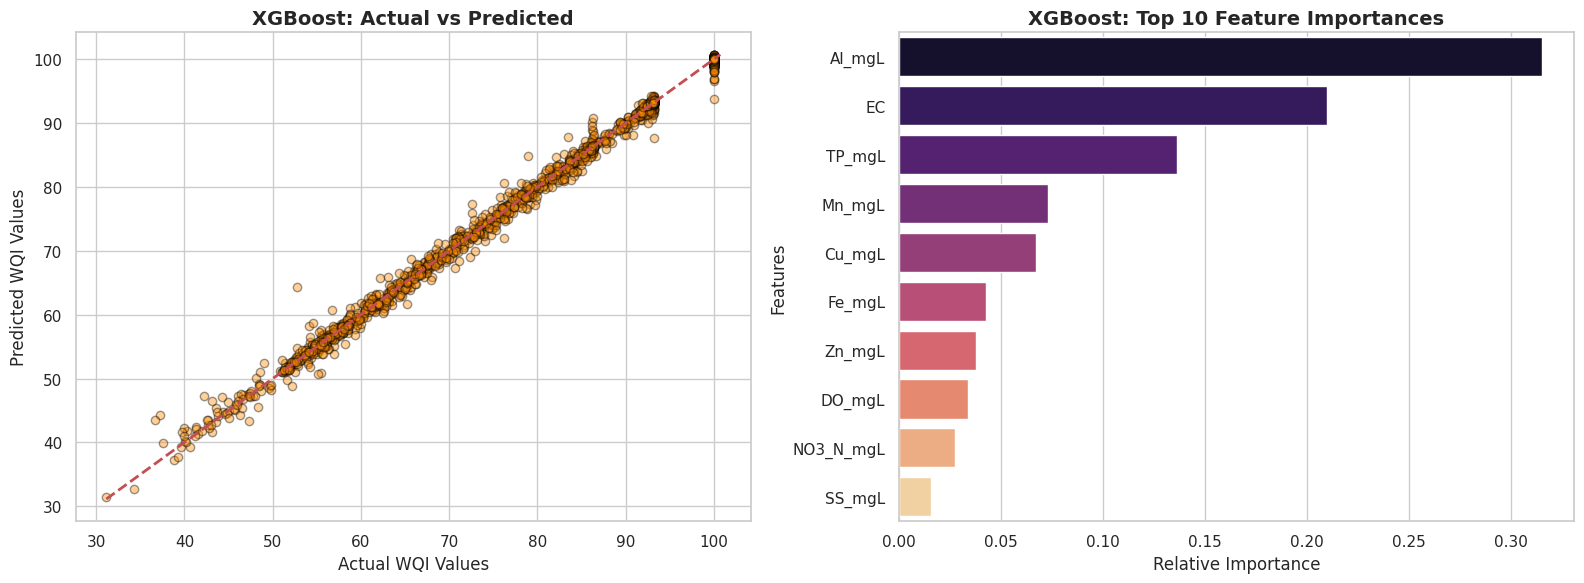

In [23]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted
sample_size = min(2000, len(y_test_xgb))

sample_idx = np.random.choice(len(y_test_xgb), size=sample_size, replace=False)

y_test_xgb_sample = (y_test_xgb.iloc[sample_idx] if isinstance(y_test_xgb, pd.Series) else y_test_xgb[sample_idx])

y_pred_xgb_sample = y_pred_xgb[sample_idx]

axes[0].scatter(y_test_xgb_sample, y_pred_xgb_sample, alpha=0.4,
                color='darkorange', edgecolors='black')

min_val = min(y_test_xgb_sample.min(), y_pred_xgb_sample.min())
max_val = max(y_test_xgb_sample.max(), y_pred_xgb_sample.max())

axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

axes[0].set_title('XGBoost: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual WQI Values', fontsize=12)
axes[0].set_ylabel('Predicted WQI Values', fontsize=12)

# Plot 2: Feature Importance
xgb_model = xgb_pipeline.named_steps['regressor']

feature_names = X_xgb.columns.tolist()

importances = xgb_model.feature_importances_

indices = np.argsort(importances)[::-1]

top_n = min(10, len(feature_names))
top_features = np.array(feature_names)[indices][:top_n]
top_importances = importances[indices][:top_n]

sns.barplot(x=top_importances, y=top_features, ax=axes[1], palette='magma')

axes[1].set_title('XGBoost: Top 10 Feature Importances', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Relative Importance', fontsize=12)
axes[1].set_ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

### 🧪 **Hybrid NN-XGBoost Model (Main)**
1. **NN:** Trained to capture complex patterns and feature interactions from the input data.
2. **Feature Extraction:** Dense feature representations are extracted from the NN's layer.
3. **XGBoost:** An XGBoost regressor is trained using these high-level extracted features to generate the final prediction.

In [24]:
df_hybrid = df_baseline.copy()

df_hybrid.head()

,EC,Temp_C,SS_mgL,pH,TP_mgL,NO2_N_mgL,NO3_N_mgL,DO_mgL,Al_mgL,Fe_mgL,...,swir22,red,blue,NDVI,NDWI,MNDWI,NDBI,NDMI,NDTI,WQI
0,30304.0,25.7,4.0,7.5,0.07,0.023,0.54,5.9,0.080,0.21,...,14592.0,9936.0,9515.5,0.736694,0.0,0.607156,-0.607156,0.607156,-0.736694,58.476165
1,44204.0,25.3,12.0,7.4,0.08,0.010,0.17,6.5,0.025,0.16,...,16477.0,65535.0,65535.0,0.000000,0.0,0.565146,-0.565146,0.565146,0.000000,54.304389
2,21510.0,28.3,24.0,7.0,0.15,0.016,0.70,7.4,0.070,0.30,...,16477.0,65535.0,65535.0,0.000000,0.0,0.565146,-0.565146,0.565146,0.000000,60.933158
3,22166.0,28.2,7.4,7.6,0.10,0.014,0.24,6.1,0.110,0.36,...,16477.0,65535.0,65535.0,0.000000,0.0,0.565146,-0.565146,0.565146,0.000000,62.530367
4,12222.0,27.8,54.0,8.0,0.13,0.012,0.31,6.8,0.710,0.63,...,16189.0,9984.0,9324.5,0.735590,0.0,0.564361,-0.564361,0.564361,-0.735590,64.919309


In [25]:
exclude_cols = ['WQI']
feature_cols = [col for col in df_hybrid.columns if col not in exclude_cols]

X_hybrid = df_hybrid[feature_cols]
y_hybrid = df_hybrid['WQI']

# Train-test split
X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(X_hybrid, y_hybrid, test_size=0.2, random_state=42)
print(f"Train size: {X_train_hybrid.shape[0]} | Test size: {X_test_hybrid.shape[0]}")

Train size: 28346 | Test size: 7087


In [26]:
print(X_hybrid.isna().sum())

EC           0
Temp_C       0
SS_mgL       0
pH           0
TP_mgL       0
NO2_N_mgL    0
NO3_N_mgL    0
DO_mgL       0
Al_mgL       0
Fe_mgL       0
Mn_mgL       0
Zn_mgL       0
Cu_mgL       0
Chl_a_mgL    0
nir          0
green        0
swir16       0
swir22       0
red          0
blue         0
NDVI         0
NDWI         0
MNDWI        0
NDBI         0
NDMI         0
NDTI         0
dtype: int64


In [27]:
scaler = StandardScaler()

X_train_hybrid_scaled = scaler.fit_transform(X_train_hybrid)
X_test_hybrid_scaled = scaler.transform(X_test_hybrid)

In [28]:
import joblib
import os

joblib.dump(scaler, os.path.join(model_dir, "scaler.pkl"), compress=0)

joblib.dump(feature_cols, os.path.join(model_dir, "feature_cols.pkl"), compress=0)

print("Scaler and feature columns saved successfully.")

Scaler and feature columns saved successfully.


In [29]:
loaded_scaler = joblib.load(os.path.join(model_dir, "scaler.pkl"))
print(type(loaded_scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>


In [30]:
# Save test dataset for inference
X_test_hybrid.to_csv(os.path.join(data_dir, "test_stream_data.csv"), index=False)
y_test_hybrid.to_csv(os.path.join(data_dir, "test_stream_target.csv"), index=False)

print("Test stream dataset saved succesfully")

Test stream dataset saved succesfully


In [31]:
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train_hybrid_scaled, y_train_hybrid, test_size=0.1, random_state=42)

In [32]:
# Data Preparation
# PyTorch NN requires (Samples, Features) input format

# --- Training tensors ---
X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_final.values, dtype=torch.float32).view(-1, 1)

# --- Validation tensors ---
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

# --- Test tensors ---
X_test_tensor = torch.tensor(X_test_hybrid_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_hybrid.values, dtype=torch.float32).view(-1, 1)

# Create DataLoader for batch training to optimize memory
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
train_loader_extract = DataLoader(train_dataset, batch_size=256, shuffle=False)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [33]:
# Define NN Architecture
class WaterQualityNN(nn.Module):
    def __init__(self, num_features):
        super(WaterQualityNN, self).__init__()

        self.feature_extractor = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.regressor = nn.Linear(64, 1)

    def forward(self, x):
        features = self.feature_extractor(x)
        output = self.regressor(features)

        return output, features

In [34]:
# Initialize NN model
print("Initializing NN model...")
sample_batch, _ = next(iter(train_loader))
num_features = sample_batch.shape[1]
nn_model = WaterQualityNN(num_features)

Initializing NN model...


In [36]:
# --- NN Training ---
criterion = nn.MSELoss()

optimizer = optim.Adam(nn_model.parameters(), lr=0.001)

epochs = 50
patience = 5
best_val_loss = float('inf')
counter = 0

print("Training NN Model...")

for epoch in range(epochs):
    # --- TRAINING ---
    nn_model.train()
    train_loss = 0.0

    train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]", leave=False)

    for batch_X, batch_y in train_progress:
        optimizer.zero_grad()

        outputs, _ = nn_model(batch_X)

        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        train_progress.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATION ---
    nn_model.eval()
    val_loss = 0.0

    val_progress = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Validation]", leave=False)

    with torch.no_grad():

        for val_X, val_y in val_progress:

            val_outputs, _ = nn_model(val_X)

            loss = criterion(val_outputs, val_y)
            val_loss += loss.item()

            val_progress.set_postfix(val_loss=loss.item())

    avg_val_loss = val_loss / len(val_loader)

    # Epoch summary
    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

        counter = 0

        torch.save(nn_model.state_dict(), os.path.join(model_dir, "best_nn_model.pth"))

        print("Validation loss improved. Model saved.")

    else:

        counter += 1
        print(f"Early Stopping Counter: " f"{counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break

Training NN Model...


Epoch [1/50] | Train Loss: 61.5202 | Val Loss: 19.1456
Validation loss improved. Model saved.


Epoch [2/50] | Train Loss: 58.9593 | Val Loss: 32.4916
Early Stopping Counter: 1/5


Epoch [3/50] | Train Loss: 58.0252 | Val Loss: 20.1536
Early Stopping Counter: 2/5


Epoch [4/50] | Train Loss: 58.8352 | Val Loss: 19.5318
Early Stopping Counter: 3/5


...

Epoch [12/50] | Train Loss: 57.6236 | Val Loss: 18.3405
Early Stopping Counter: 1/5


Epoch [13/50] | Train Loss: 56.1262 | Val Loss: 29.8929
Early Stopping Counter: 2/5


Epoch [14/50] | Train Loss: 55.2123 | Val Loss: 13.0432
Early Stopping Counter: 3/5


Epoch [15/50] | Train Loss: 55.3476 | Val Loss: 17.0078
Early Stopping Counter: 4/5


Epoch [16/50] | Train Loss: 53.8576 | Val Loss: 11.8729
Early Stopping Counter: 5/5
Early stopping triggered.


In [37]:
model_dir = os.path.join(base_dir, "model")

# Load NN model
nn_model.load_state_dict(torch.load(os.path.join(model_dir, "best_nn_model.pth")))

<All keys matched successfully>

In [38]:
# Extract Features & Train XGBoost
print("Extracting NN Features...")
nn_model.eval()

# -- Train Features --
train_features_list = []

with torch.no_grad():
    for batch_X, _ in tqdm(train_loader_extract, desc="Extracting Train NN Features"):
        _, batch_features = nn_model(batch_X)

        train_features_list.append(batch_features.cpu().numpy())

train_hybrid_nn_xgb_features_np = np.vstack(train_features_list)

# -- Test Features --
test_features_list = []

with torch.no_grad():
    for batch_X, _ in tqdm(test_loader, desc="Extracting Test NN Features"):
        _, batch_features = nn_model(batch_X)

        test_features_list.append(batch_features.cpu().numpy())

test_hybrid_nn_xgb_features_np = np.vstack(test_features_list)

print(f"Extracted features shape: {test_hybrid_nn_xgb_features_np.shape}")

# Train Hybrid NN-XGBoost Regressor
print("Training Hybrid NN-XGBoost: ")

hybrid_nn_xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                              subsample=0.8, colsample_bytree=0.8, random_state=42,
                              objective='reg:squarederror', n_jobs=1)

hybrid_nn_xgb_model.fit(train_hybrid_nn_xgb_features_np, y_train_final)

with open(os.path.join(model_dir, "best_hybrid_nn_xgb_model.pkl"), 'wb') as f:
    pickle.dump(hybrid_nn_xgb_model, f)

print(f"✅ Hybrid NN-XGBoost model saved to {os.path.join(model_dir, 'best_hybrid_nn_xgb_model.pkl')}")

Extracting NN Features...


Extracting Test NN Features: 100%|██████████| 28/28 [00:00<00:00, 389.88it/s]


Extracted features shape: (7087, 64)
Training Hybrid NN-XGBoost: 
✅ Hybrid NN-XGBoost model saved to /home/jupyter/src/model/best_hybrid_nn_xgb_model.pkl


### ✅ **Hybrid NN-XGBoost Model Evaluation and Visual Analysis**
We evaluate the Hybrid NN-XGBoost's model performance using standard regression metrics (R2, RMSE, and MAE).

Furthermore, we generate visual plots (Actual vs. Predicted curve and Feature Importance) to clearly interpret the results and identify which data indicators are the main drivers of the water quality index.

In [39]:
# Predict on test set
y_pred_hybrid = hybrid_nn_xgb_model.predict(test_hybrid_nn_xgb_features_np)

rmse_hybrid = np.sqrt(mean_squared_error(y_test_hybrid, y_pred_hybrid))
mae_hybrid = mean_absolute_error(y_test_hybrid, y_pred_hybrid)
r2_hybrid = r2_score(y_test_hybrid, y_pred_hybrid)

print("Hybrid NN-XGBoost (Main) Evaluation Results: ")
print(f"RMSE: {rmse_hybrid:.4f}")
print(f"MAE:  {mae_hybrid:.4f}")
print(f"R2 Score: {r2_hybrid:.4f}")

Hybrid NN-XGBoost (Main) Evaluation Results: 
RMSE: 2.4829
MAE:  1.6697
R2 Score: 0.9792


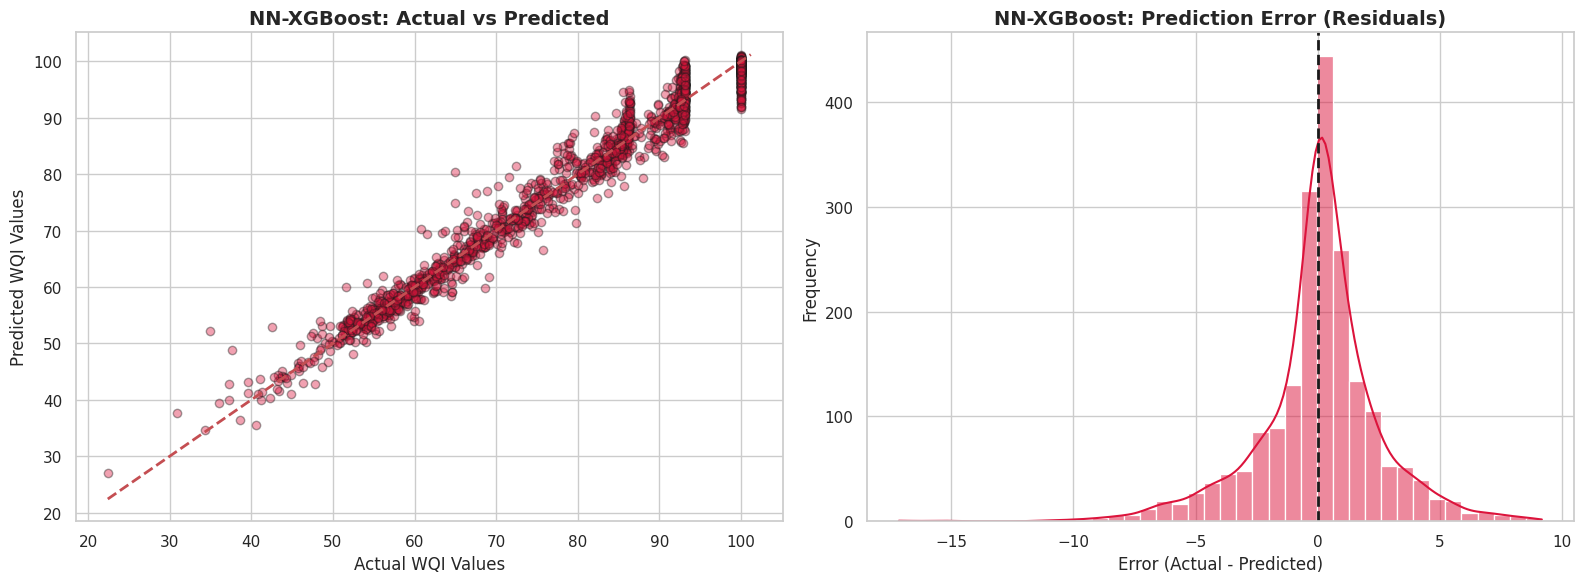

In [40]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted
sample_size = min(2000, len(y_test_hybrid))

sample_idx = np.random.choice(len(y_test_hybrid), size=sample_size, replace=False)

y_test_hybrid_sample = (y_test_hybrid.iloc[sample_idx] if isinstance(y_test_hybrid, pd.Series) else y_test_hybrid[sample_idx])

y_pred_hybrid_sample = y_pred_hybrid[sample_idx]

axes[0].scatter(y_test_hybrid_sample, y_pred_hybrid_sample, alpha=0.4,
                color='crimson', edgecolors='k')

min_val = min(y_test_hybrid_sample.min(), y_pred_hybrid_sample.min())
max_val = max(y_test_hybrid_sample.max(), y_pred_hybrid_sample.max())

axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

axes[0].set_title('Hybrid NN-XGBoost: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual WQI Values', fontsize=12)
axes[0].set_ylabel('Predicted WQI Values', fontsize=12)

# Plot 2 Prediction Error (Residuals)
# Calculate residuals (Actual - Predicted)
residuals = y_test_hybrid_sample - y_pred_hybrid_sample
sns.histplot(residuals, kde=True, ax=axes[1], color='crimson', bins=40)

axes[1].set_title('Hybrid NN-XGBoost: Prediction Error (Residuals)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Error (Actual - Predicted)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

# Add perfect reference line (x=0)
axes[1].axvline(0, color='k', linestyle='--', lw=2)

plt.tight_layout()
plt.show()

--- Final Model Comparison Summary ---


,Model,RMSE,MAE,R2 Score
0,XGBoost,0.943153,0.529217,0.997004
1,Hybrid NN-XGBoost,2.482878,1.669655,0.979237


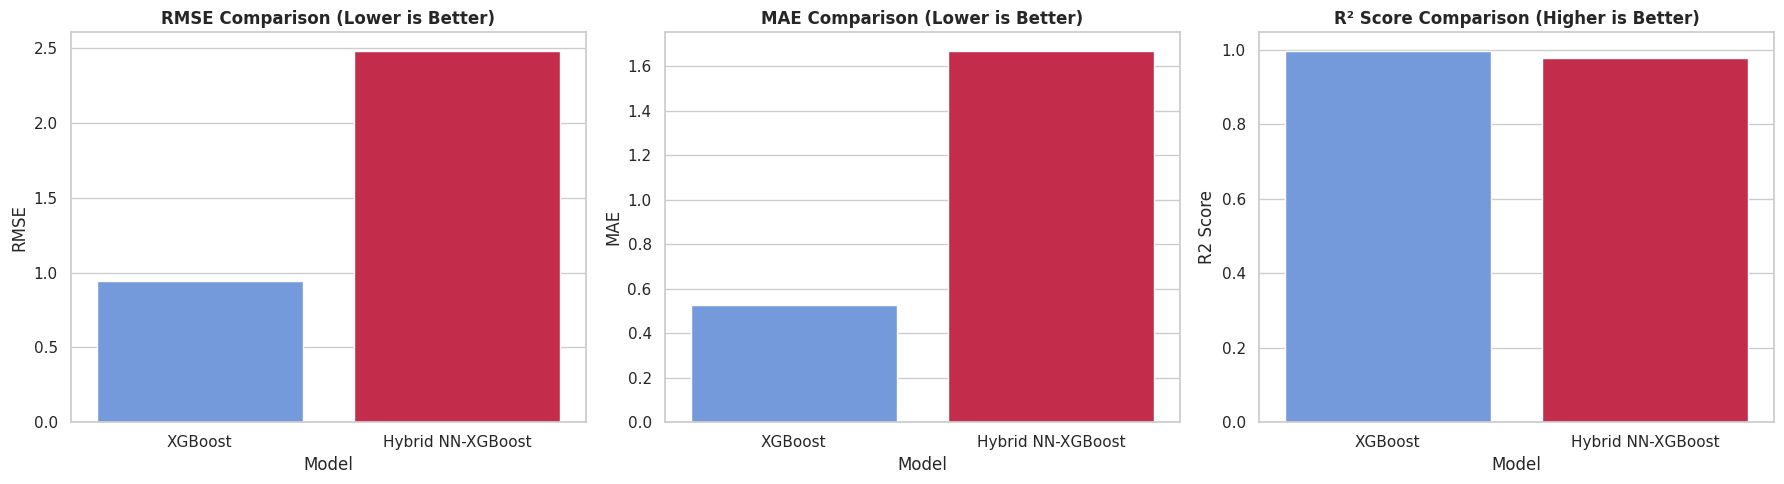

In [41]:
# Aggregate evaluation metrics dynamically from previous outputs
comparison_data = {
    'Model': ['XGBoost', 'Hybrid NN-XGBoost'],
    'RMSE': [rmse_xgb, rmse_hybrid],
    'MAE': [mae_xgb, mae_hybrid],
    'R2 Score': [r2_xgb, r2_hybrid]
}

df_compare = pd.DataFrame(comparison_data)

print("--- Final Model Comparison Summary ---")
display(df_compare)

# Plot comparison bar charts
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define color palette: blue for baselines, red to highlight the hybrid model
colors = ['cornflowerblue', 'crimson']

# Plot RMSE
sns.barplot(x='Model', y='RMSE', data=df_compare, ax=axes[0], palette=colors, hue='Model', legend=False)
axes[0].set_title('RMSE Comparison (Lower is Better)', fontweight='bold')

# Plot MAE
sns.barplot(x='Model', y='MAE', data=df_compare, ax=axes[1], palette=colors, hue='Model', legend=False)
axes[1].set_title('MAE Comparison (Lower is Better)', fontweight='bold')

# Plot R2 Score
sns.barplot(x='Model', y='R2 Score', data=df_compare, ax=axes[2], palette=colors, hue='Model', legend=False)
axes[2].set_title('R² Score Comparison (Higher is Better)', fontweight='bold')

plt.tight_layout()
plt.show()

In [42]:
!gsutil cp model/* gs://river-water-quality-bucket/model/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://model/best_hybrid_nn_xgb_model.pkl [Content-Type=application/octet-stream]...
Copying file://model/best_nn_model.pth [Content-Type=application/octet-stream]...
Copying file://model/feature_cols.pkl [Content-Type=application/octet-stream]...
Copying file://model/scaler.pkl [Content-Type=application/octet-stream]...      
- [4 files][  1.3 MiB/  1.3 MiB]                                                
==> NOTE: You are performing a sequence of gsutil operations that may
run significantly faster if you instead use gsutil -m cp ... Please
see the -m section under "gsutil help options" for further information
about when gsutil -m can be advantageous.

Copying file://model/xgb_model.pkl [Content-Type=application/octet-stre